In [1]:
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, dendrogram
TRAIN_PATH = "../data/processed/train.parquet"

In [2]:
prices = (
    pl.scan_parquet(TRAIN_PATH)
    .filter(pl.col("metric").str.starts_with("price"))
    .collect()
    .pivot(values="value", index="day_utc", on="metric")
    .sort("day_utc")
    .to_pandas()
    .set_index("day_utc")
    .apply(pd.to_numeric, errors="coerce")
)

In [3]:
prices = prices.dropna(axis=1, thresh=int(0.5 * len(prices)))
prices = prices.fillna(prices.median())
prices = prices.loc[:, prices.nunique() > 1]

print(f"Shape after cleaning: {prices.shape}")


corr = prices.corr(method="pearson")

Shape after cleaning: (5471, 6045)


In [4]:
dist = squareform(1 - corr.abs(), checks=False)
Z = linkage(dist, method="ward")

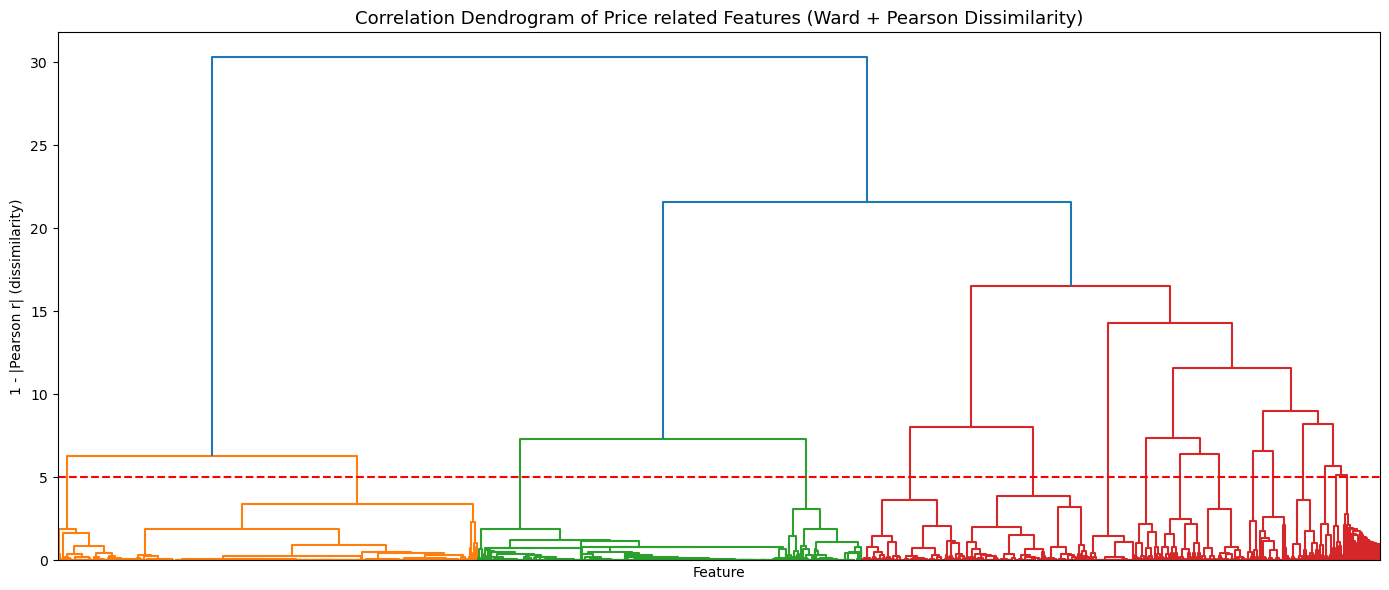

In [7]:
fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(Z, no_labels=True, ax=ax)
ax.set_title("Correlation Dendrogram of Price related Features (Ward + Pearson Dissimilarity)", fontsize=13)
ax.set_xlabel("Feature")
ax.set_ylabel("1 - |Pearson r| (dissimilarity)")
plt.axhline(y=5, color="red", linestyle="--", label="Dissimilarity Threshold (0.5)")
plt.tight_layout()
plt.show()

In [8]:
from scipy.cluster.hierarchy import fcluster

clusters_price = fcluster(Z, t=15, criterion="maxclust")

cluster_map_price = dict(zip(prices.columns, clusters_price))


cluster_df_price = pd.DataFrame({
    "feature": prices.columns,
    "cluster": clusters_price
})
cluster_df_price.head()

,feature,cluster
0,price_111d_sma,2
1,price_111d_sma_ratio,7
2,price_111d_sma_ratio_0sd_usd,2
3,price_111d_sma_ratio_0sd_usd_sats,7
4,price_111d_sma_ratio_1m_sma,11


In [20]:
cluster_df_price.value_counts("cluster").sort_index()

cluster
1      365
2     1556
3     1411
4      342
5      480
6      567
7      200
8      124
9      186
10     202
11      64
12     143
13     128
14      60
15     217
Name: count, dtype: int64

In [21]:
zoom_cols = cluster_df_price[cluster_df_price["cluster"] == 14]["feature"].tolist()
zoom_cols

['price_12d_ema_ratio_pct1',
 'price_12d_ema_ratio_pct2',
 'price_12d_ema_ratio_pct5',
 'price_13d_ema_ratio_pct1',
 'price_13d_ema_ratio_pct2',
 'price_13d_ema_ratio_pct5',
 'price_13d_sma_ratio_pct1',
 'price_13d_sma_ratio_pct2',
 'price_13d_sma_ratio_pct5',
 'price_1m_ema_ratio_1y_m3sd_usd_sats',
 'price_1m_ema_ratio_4y_m3sd_usd_sats',
 'price_1m_ema_ratio_m3sd_usd_sats',
 'price_1m_ema_ratio_pct1',
 'price_1m_ema_ratio_pct2',
 'price_1m_ema_ratio_pct5',
 'price_1m_sma_ratio_1y_m2_5sd_usd_sats',
 'price_1m_sma_ratio_4y_m3sd_usd_sats',
 'price_1m_sma_ratio_m3sd_usd_sats',
 'price_1m_sma_ratio_pct1',
 'price_1m_sma_ratio_pct2',
 'price_1m_sma_ratio_pct5',
 'price_1w_ema_ratio_pct1',
 'price_1w_ema_ratio_pct2',
 'price_1w_ema_ratio_pct5',
 'price_1w_sma_ratio_pct1',
 'price_1w_sma_ratio_pct2',
 'price_1w_sma_ratio_pct5',
 'price_21d_ema_ratio_pct1',
 'price_21d_ema_ratio_pct2',
 'price_21d_ema_ratio_pct5',
 'price_21d_sma_ratio_1y_m3sd_usd_sats',
 'price_21d_sma_ratio_pct1',
 'price_21

/var/folders/8t/x329s8055vdgtxtnhtz6vkzr0000gn/T/ipykernel_60908/953973441.py:37: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


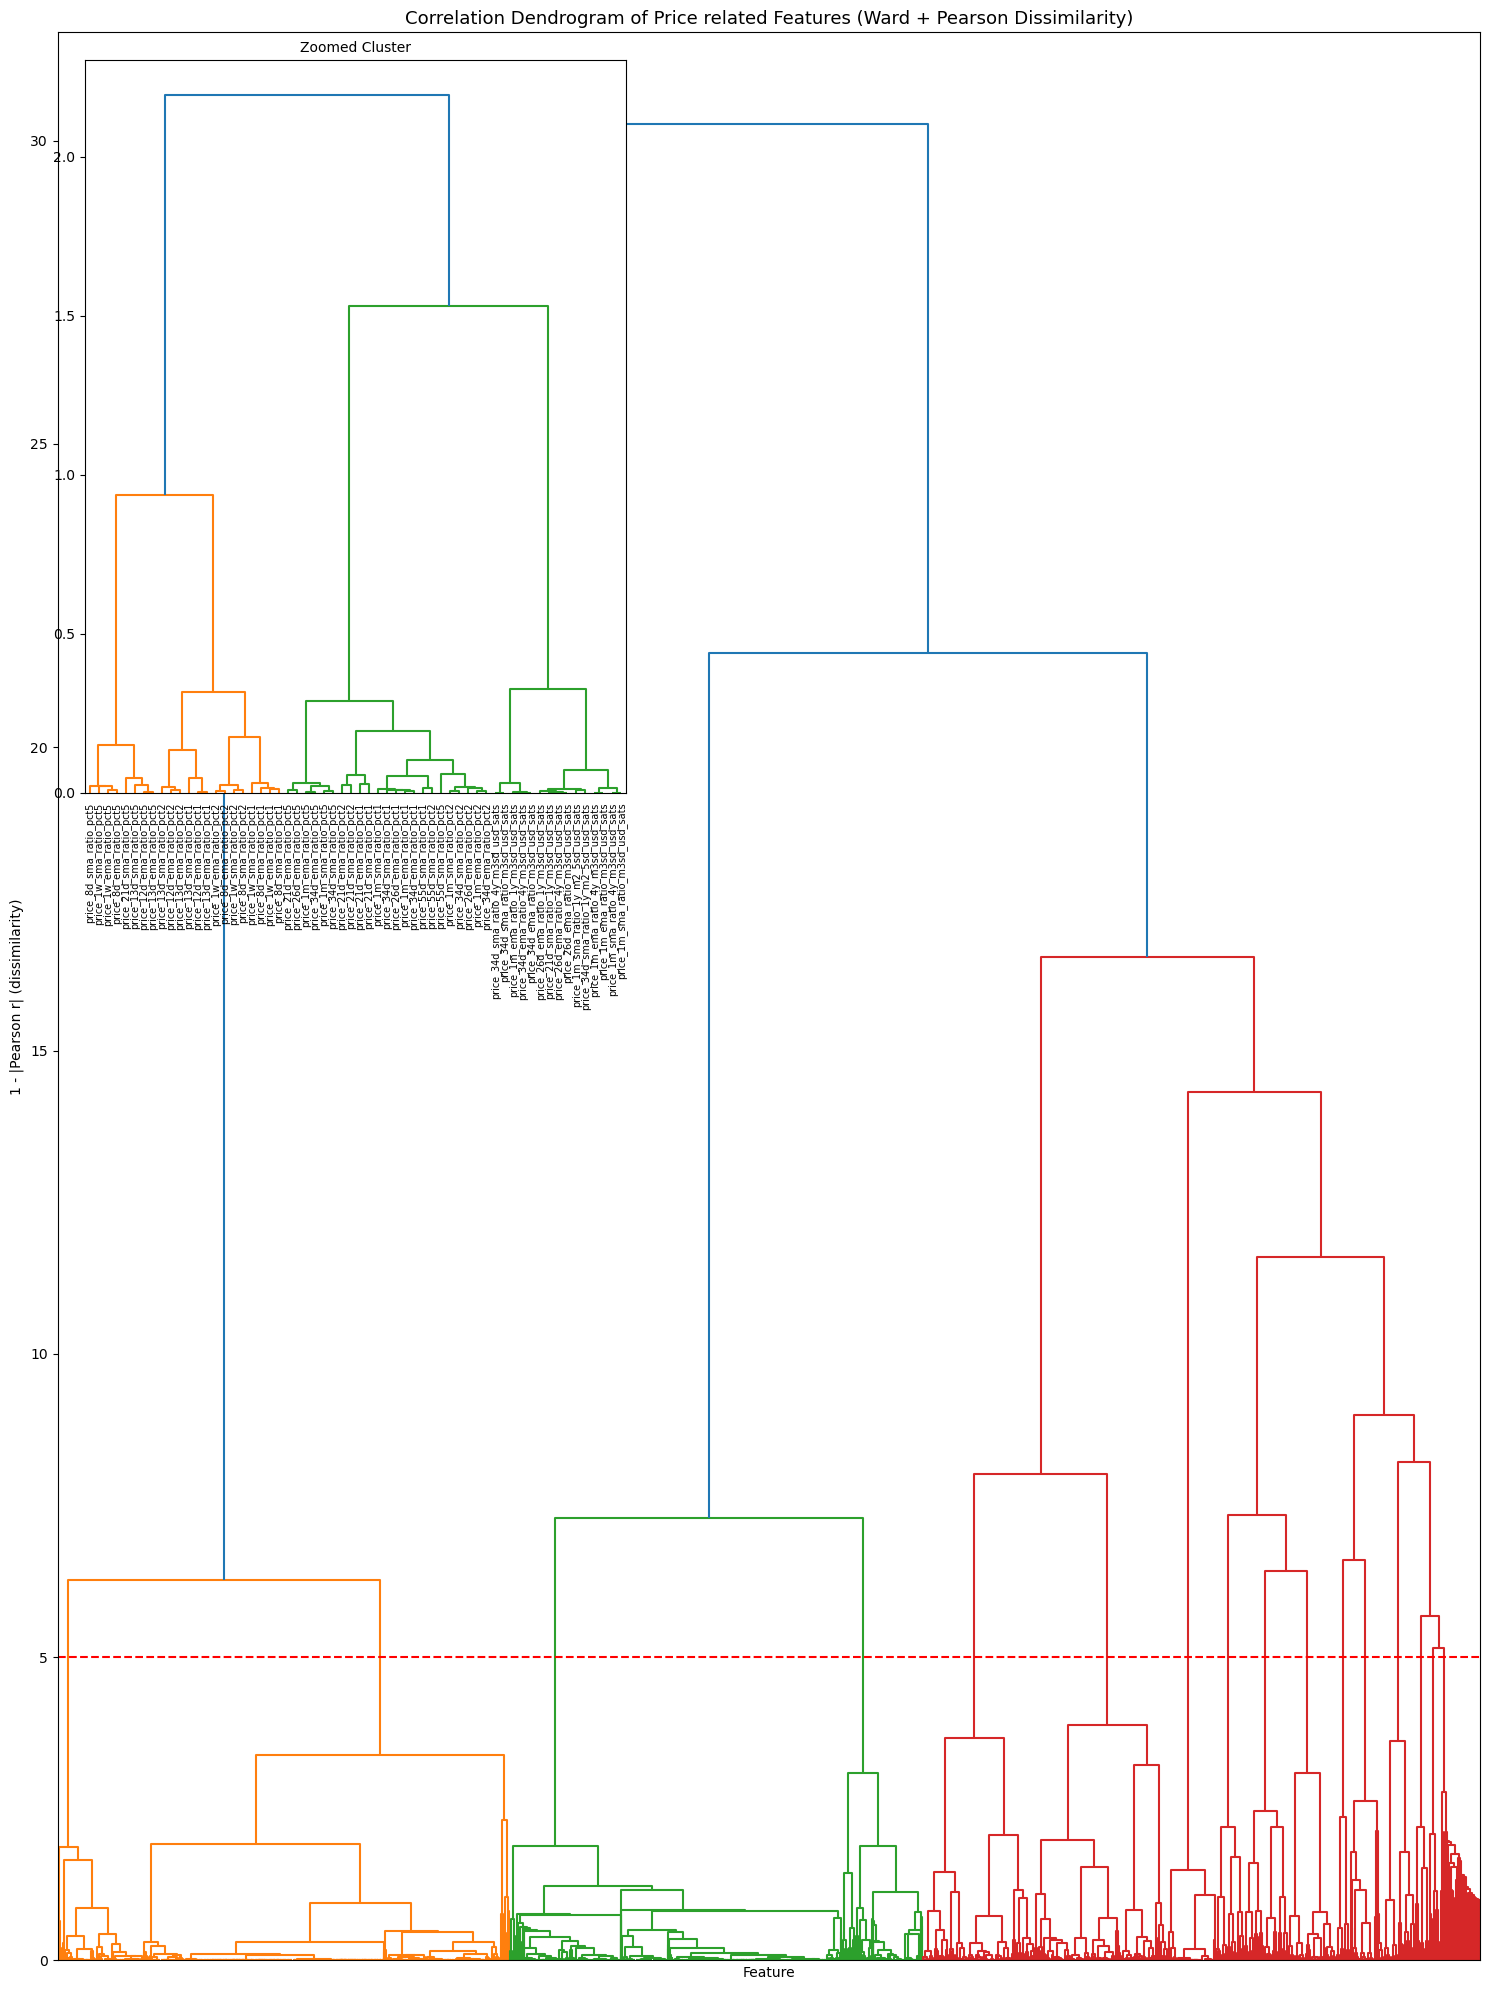

In [28]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
fig, ax = plt.subplots(figsize=(15, 20))
dendrogram(Z, no_labels=True, ax=ax)
ax.set_title("Correlation Dendrogram of Price related Features (Ward + Pearson Dissimilarity)", fontsize=13)
ax.set_xlabel("Feature")
ax.set_ylabel("1 - |Pearson r| (dissimilarity)")
plt.axhline(y=5, color="red", linestyle="--")

# -----------------------------
# 2. Inset dendrogram
# -----------------------------
zoom_corr = prices[zoom_cols].corr(method="pearson").abs()
zoom_dist = 1 - zoom_corr

Z_zoom = linkage(squareform(zoom_dist, checks=False), method="ward")

axins = inset_axes(
    ax,
    width="38%",
    height="38%",
    loc="upper left",
    borderpad=2
)

dendrogram(
    Z_zoom,
    labels=zoom_cols,
    ax=axins,
    leaf_rotation=90,
    leaf_font_size=7
)

axins.set_title("Zoomed Cluster", fontsize=10)
axins.set_ylabel("")
axins.set_xlabel("")

plt.tight_layout()
plt.show()